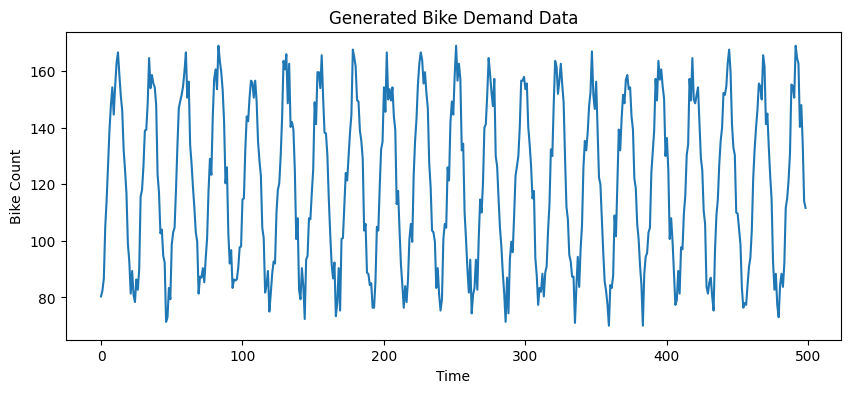

Mean Absolute Error (MAE): 5.34
Root Mean Squared Error (RMSE): 6.28


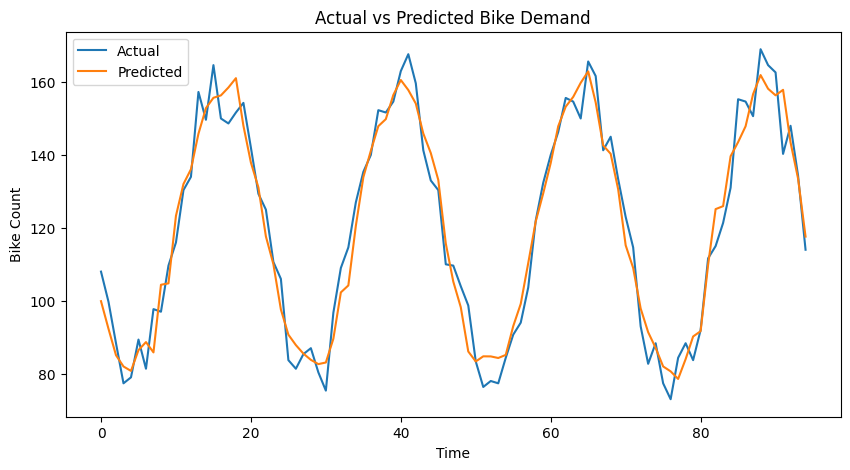

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
import math

hours = np.arange(1, 500)

bike_demand = 120 + 40*np.sin((hours-6)/24*2*np.pi)
bike_demand = bike_demand + np.random.randint(-10, 10, size=len(hours))

data = pd.DataFrame(bike_demand, columns=["Bike_Count"])

plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Generated Bike Demand Data")
plt.xlabel("Time")
plt.ylabel("Bike Count")
plt.show()



scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=24):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)

# Flatten input for MLP
X = X.reshape(X.shape[0], X.shape[1])

# Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]



model = MLPRegressor(hidden_layer_sizes=(64, 32),
                     activation='relu',
                     solver='adam',
                     max_iter=500,
                     random_state=42)

model.fit(X_train, y_train)


test_predict = model.predict(X_test)

# Inverse transform
test_predict = scaler.inverse_transform(test_predict.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))



mae = mean_absolute_error(y_test_actual, test_predict)
rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))

print("Mean Absolute Error (MAE):", round(mae,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))



plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(test_predict, label="Predicted")
plt.title("Actual vs Predicted Bike Demand")
plt.xlabel("Time")
plt.ylabel("Bike Count")
plt.legend()
plt.show()